In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv


In [2]:
import pandas as pd
df=pd.read_csv('/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv')
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


Initial Shape: (1500, 11)

Missing Values Before:
 Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

Missing Values After:
 Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

Removed 0 duplicate rows
Shape After Outlier Removal: (1500, 11)

===== KEY INSIGHTS =====
Average GPA Before AI: 3.26
Average GPA After AI: 3.34
Average GPA Change: 0.088

Top AI Usage Cases:
 Main_Usage_Case
Exam Prep            341
Literature Review    308


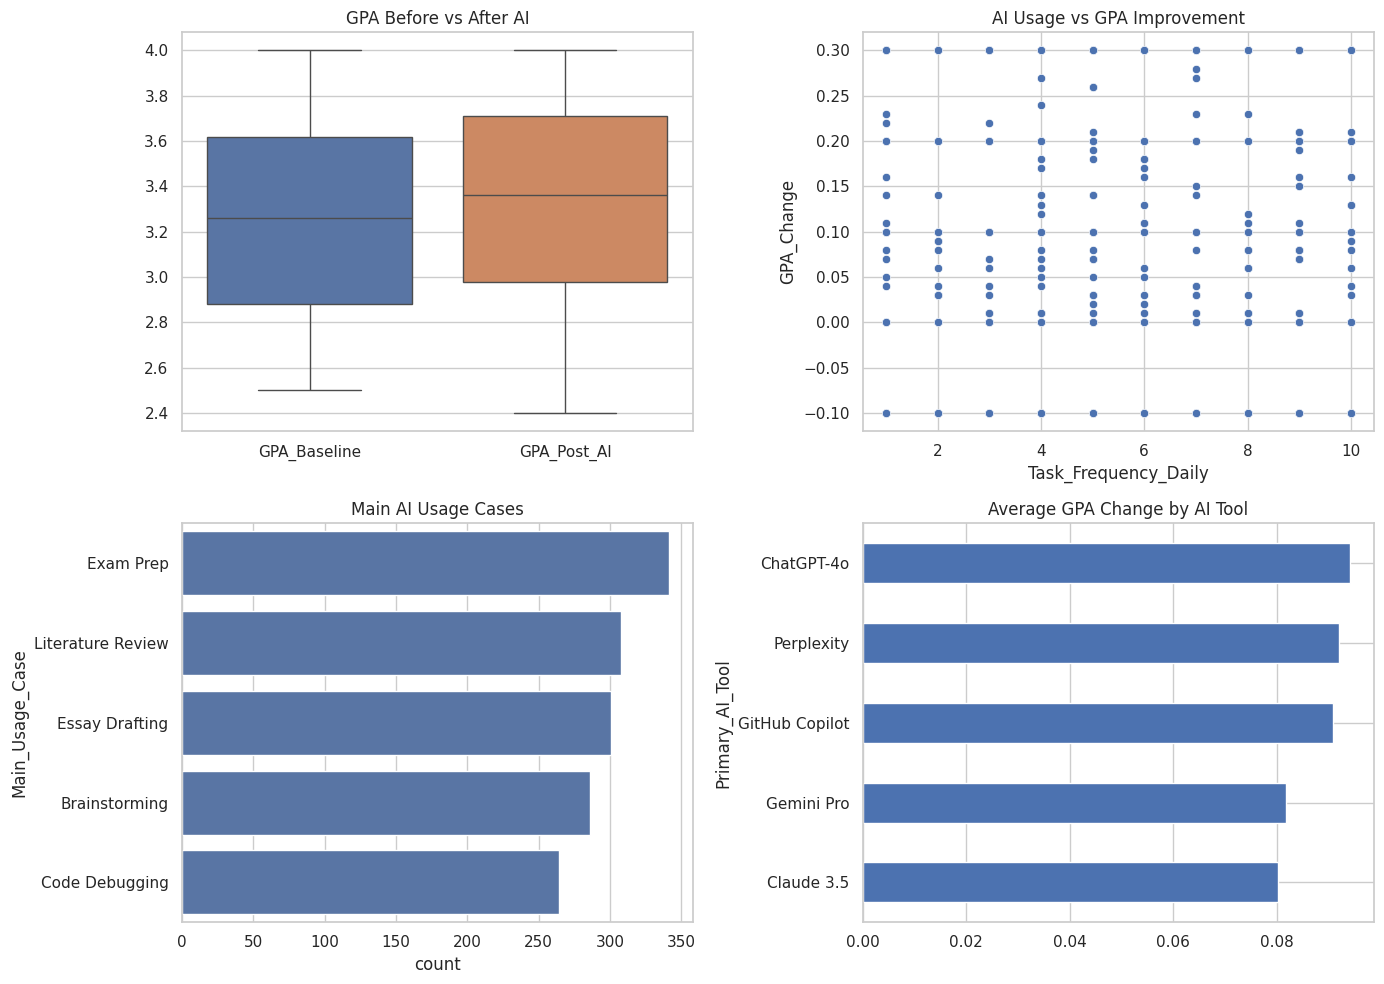

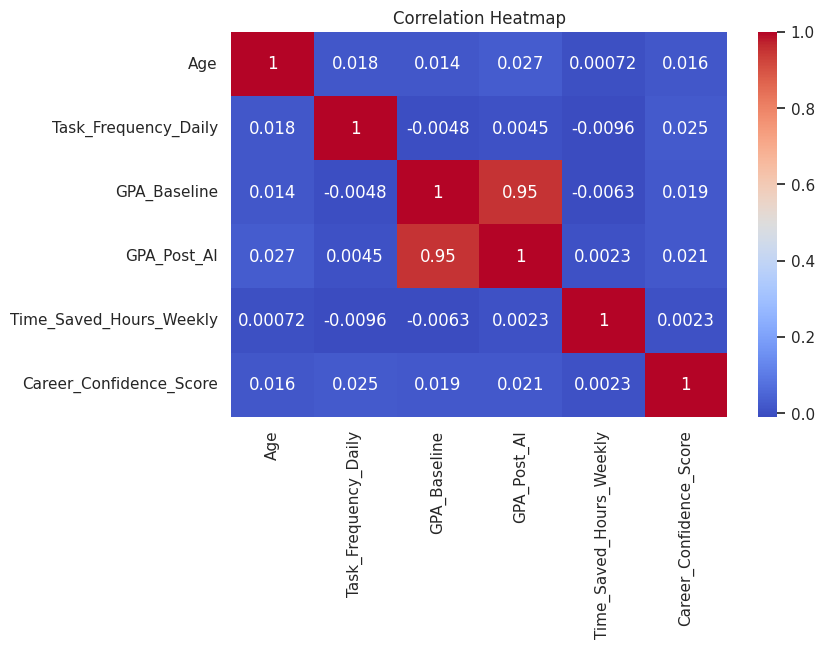

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#Load Dataset

df=pd.read_csv('/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv')
df.head()
print("Initial Shape:", df.shape)

#Handle Missing Values

print("\nMissing Values Before:\n", df.isnull().sum())

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0])


print("\nMissing Values After:\n", df.isnull().sum())

#Remove Duplicates

before = df.shape[0]
df = df.drop_duplicates().copy()
after = df.shape[0]
print(f"\nRemoved {before - after} duplicate rows")

#Handle Outliers

def remove_outliers(data, cols):
    clean_df = data.copy()
    for col in cols:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]
    return clean_df

df = remove_outliers(df, num_cols)
print("Shape After Outlier Removal:", df.shape)

#Feature Engineering

df['GPA_Change'] = df['GPA_Post_AI'] - df['GPA_Baseline']

#Basic Insights

print("\n===== KEY INSIGHTS =====")
print("Average GPA Before AI:", round(df['GPA_Baseline'].mean(), 2))
print("Average GPA After AI:", round(df['GPA_Post_AI'].mean(), 2))
print("Average GPA Change:", round(df['GPA_Change'].mean(), 3))

print("\nTop AI Usage Cases:\n", df['Main_Usage_Case'].value_counts().head())
print("\nTop AI Tools:\n", df['Primary_AI_Tool'].value_counts().head())

#Visualization Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.boxplot(data=df[['GPA_Baseline','GPA_Post_AI']], ax=axes[0,0])
axes[0,0].set_title("GPA Before vs After AI")

sns.scatterplot(x='Task_Frequency_Daily', y='GPA_Change', data=df, ax=axes[0,1])
axes[0,1].set_title("AI Usage vs GPA Improvement")

sns.countplot(
    y='Main_Usage_Case',
    data=df,
    order=df['Main_Usage_Case'].value_counts().index,
    ax=axes[1,0]
)
axes[1,0].set_title("Main AI Usage Cases")

df.groupby('Primary_AI_Tool')['GPA_Change'].mean().sort_values().plot(
    kind='barh', ax=axes[1,1]
)
axes[1,1].set_title("Average GPA Change by AI Tool")

plt.tight_layout()
plt.show()

#Correlation Heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



